# Evaluate MRL Model Quality (MRL Quality Evaluation)

This notebook is built around 4 strict criteria to evaluate whether an MRL model is truly "good":
1. **Truncation Decay (Quality Degradation):** Measured by Spearman correlation (Spearman's Rank Correlation) between cosine scores of the original vector (512D) and truncated vectors.
2. **Classification / Retrieval:** Measures accuracy (Recall@K / mAP) to check whether performance remains strong at lower dimensions.
3. **Cost-Optimal Curve (Pareto Frontier):** Plots the trade-off between Accuracy and Compute Cost (FLOPs).

In [6]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
import time

%matplotlib inline
%config InlineBackend.figure_format='retina'

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cpu


## 1. Load Real Embedding Data
We will load the extracted feature files from the project's Test set (located in `ai-worker/embeddings/`).

In [7]:
try:
    image_features = torch.load('../ai-worker/embeddings/test_image_features.pt', map_location=device)
    text_features = torch.load('../ai-worker/embeddings/test_text_features.pt', map_location=device)
    print(f"Loaded Image Features Shape: {image_features.shape}")
    print(f"Loaded Text Features Shape:  {text_features.shape}")
except Exception as e:
    print("Feature files not found. Generating mock data to simulate the algorithm...")
    # Generate mock data if extract_features.py has not been run
    image_features = torch.randn(2000, 512, device=device)
    text_features = torch.randn(2000, 512, device=device)

BASE_DIM = image_features.shape[1]
mrl_dims = [16, 32, 64, 128, 256, BASE_DIM]

Loaded Image Features Shape: torch.Size([2179, 512])
Loaded Text Features Shape:  torch.Size([2179, 512])


## 2. Criterion 1: Truncation Decay (Spearman Correlation)
We treat the full `512D` Cosine Similarity matrix as the **Ground Truth**. At each truncated level (for example, 128D), we recompute a new Cosine Similarity matrix.
Then, we compute Spearman's rank correlation (Spearman's Rho) between these two matrices. If the coefficient is > 0.95 (95%), truncation almost does not change the ranking order of search results!

Computing the base Cosine Similarity matrix (512D)...
Dimension  16 -> Spearman's Rho: 0.7118
Dimension  32 -> Spearman's Rho: 0.8083
Dimension  64 -> Spearman's Rho: 0.8609
Dimension 128 -> Spearman's Rho: 0.9150
Dimension 256 -> Spearman's Rho: 0.9601
Dimension 512 -> Spearman's Rho: 1.0000


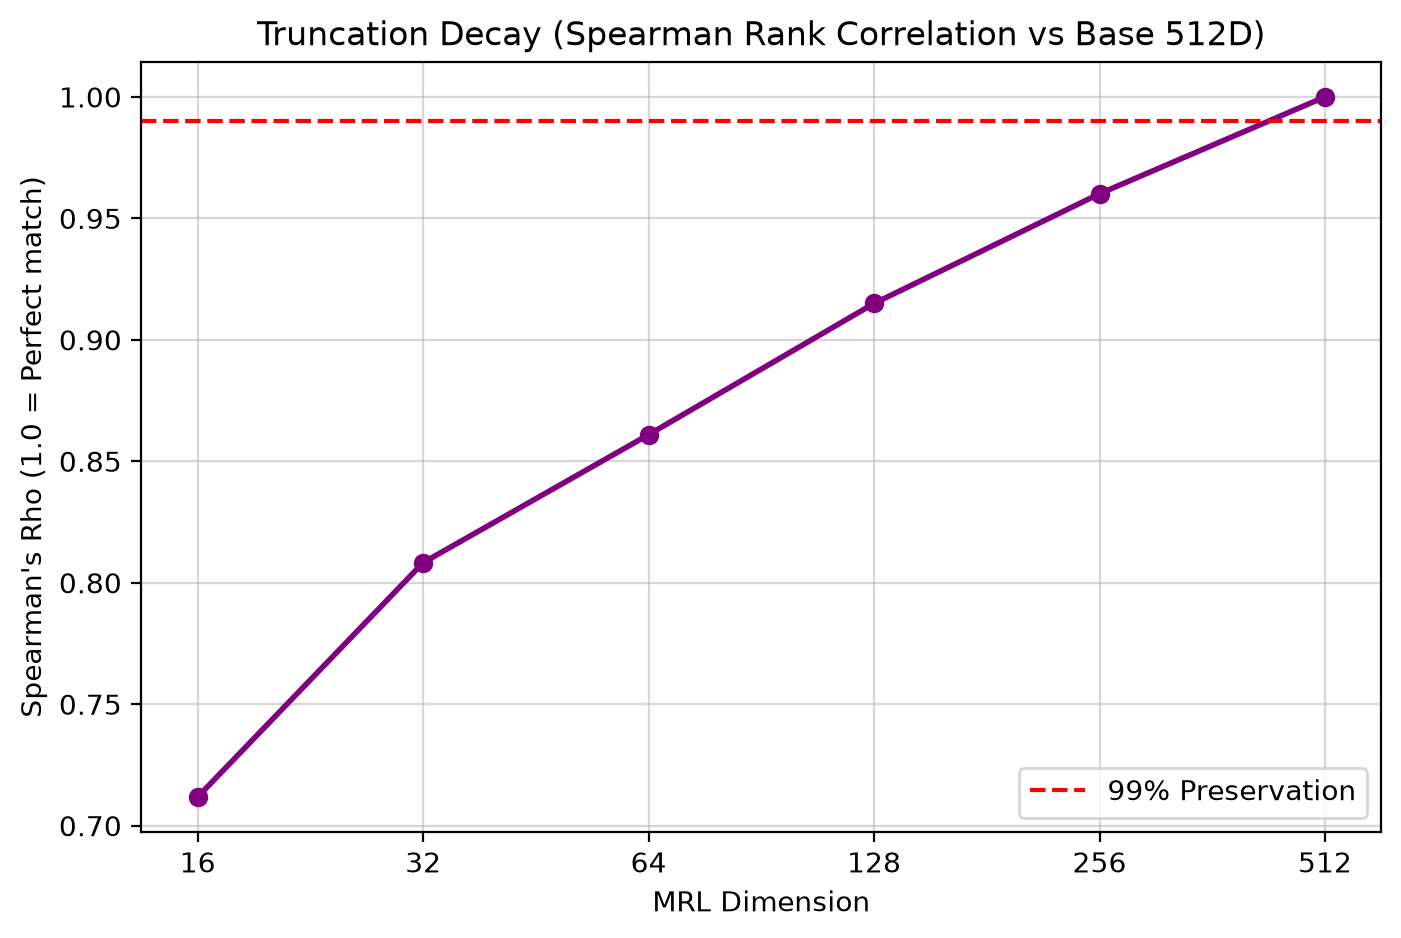

In [8]:
# Function to compute Cosine Similarity Matrix
def compute_sim_matrix(img_feat, txt_feat, dim):
    img_slice = F.normalize(img_feat[:, :dim], p=2, dim=1)
    txt_slice = F.normalize(txt_feat[:, :dim], p=2, dim=1)
    return torch.matmul(txt_slice, img_slice.T).cpu().numpy().flatten()

print("Computing the base Cosine Similarity matrix (512D)...")
sim_base = compute_sim_matrix(image_features, text_features, BASE_DIM)

spearman_scores = []
for dim in mrl_dims:
    sim_cut = compute_sim_matrix(image_features, text_features, dim)
    # Compute Spearman Rank Correlation (rank comparison)
    rho, _ = spearmanr(sim_base, sim_cut)
    spearman_scores.append(rho)
    print(f"Dimension {dim:3d} -> Spearman's Rho: {rho:.4f}")

# Plot the chart
plt.figure(figsize=(8, 5))
plt.plot(mrl_dims, spearman_scores, marker='o', color='purple', linewidth=2)
plt.title('Truncation Decay (Spearman Rank Correlation vs Base 512D)')
plt.xlabel('MRL Dimension')
plt.ylabel("Spearman's Rho (1.0 = Perfect match)")
plt.axhline(y=0.99, color='r', linestyle='--', label='99% Preservation')
plt.xscale('log', base=2)
plt.xticks(mrl_dims, labels=[str(d) for d in mrl_dims])
plt.grid(True, alpha=0.5)
plt.legend()
plt.show()

## 3. Criteria 2 & 3: Retrieval Performance (Recall@10)
A "good" MRL model should keep Recall@10 very stable until it is truncated to extreme levels (such as 16D).

Dimension  16 -> Recall@10: 89.67%
Dimension  32 -> Recall@10: 92.93%
Dimension  64 -> Recall@10: 93.48%
Dimension 128 -> Recall@10: 93.99%
Dimension 256 -> Recall@10: 94.81%
Dimension 512 -> Recall@10: 94.72%


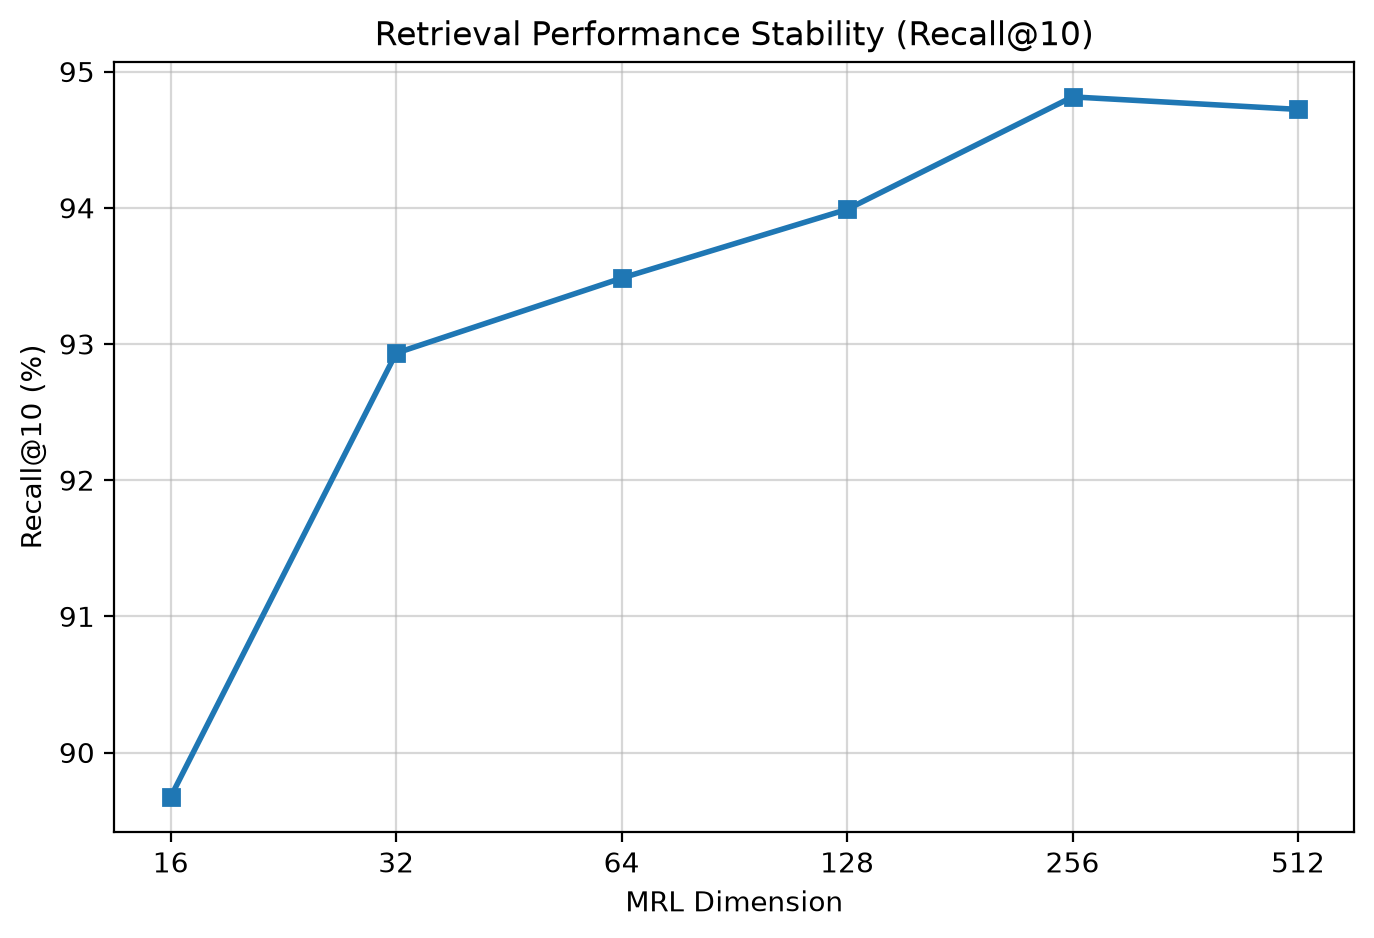

In [9]:
recall_at_10 = []
num_queries = text_features.shape[0]

# Ground truth id is the diagonal itself (text i corresponds to image i)
ground_truth_idx = torch.arange(num_queries, device=device)

for dim in mrl_dims:
    img_slice = F.normalize(image_features[:, :dim], p=2, dim=1)
    txt_slice = F.normalize(text_features[:, :dim], p=2, dim=1)
    
    sim_matrix = torch.matmul(txt_slice, img_slice.T)
    top10_preds = torch.topk(sim_matrix, k=10, dim=1).indices
    
    # Compute Recall@10
    correct = (top10_preds == ground_truth_idx.view(-1, 1)).sum().item()
    acc = (correct / num_queries) * 100
    recall_at_10.append(acc)
    
    print(f"Dimension {dim:3d} -> Recall@10: {acc:.2f}%")

plt.figure(figsize=(8, 5))
plt.plot(mrl_dims, recall_at_10, marker='s', color='#1f77b4', linewidth=2)
plt.title('Retrieval Performance Stability (Recall@10)')
plt.xlabel('MRL Dimension')
plt.ylabel('Recall@10 (%)')
plt.xscale('log', base=2)
plt.xticks(mrl_dims, labels=[str(d) for d in mrl_dims])
plt.grid(True, alpha=0.5)
plt.show()

## 4. Criterion 4: Cost-Optimal Curve (Pareto Frontier)
Represents the trade-off between **Accuracy (Recall@10)** and **FLOPs (Compute cost)**.
For Cross-Modal Retrieval (Dot Product), the number of operations is proportional to the vector dimension.

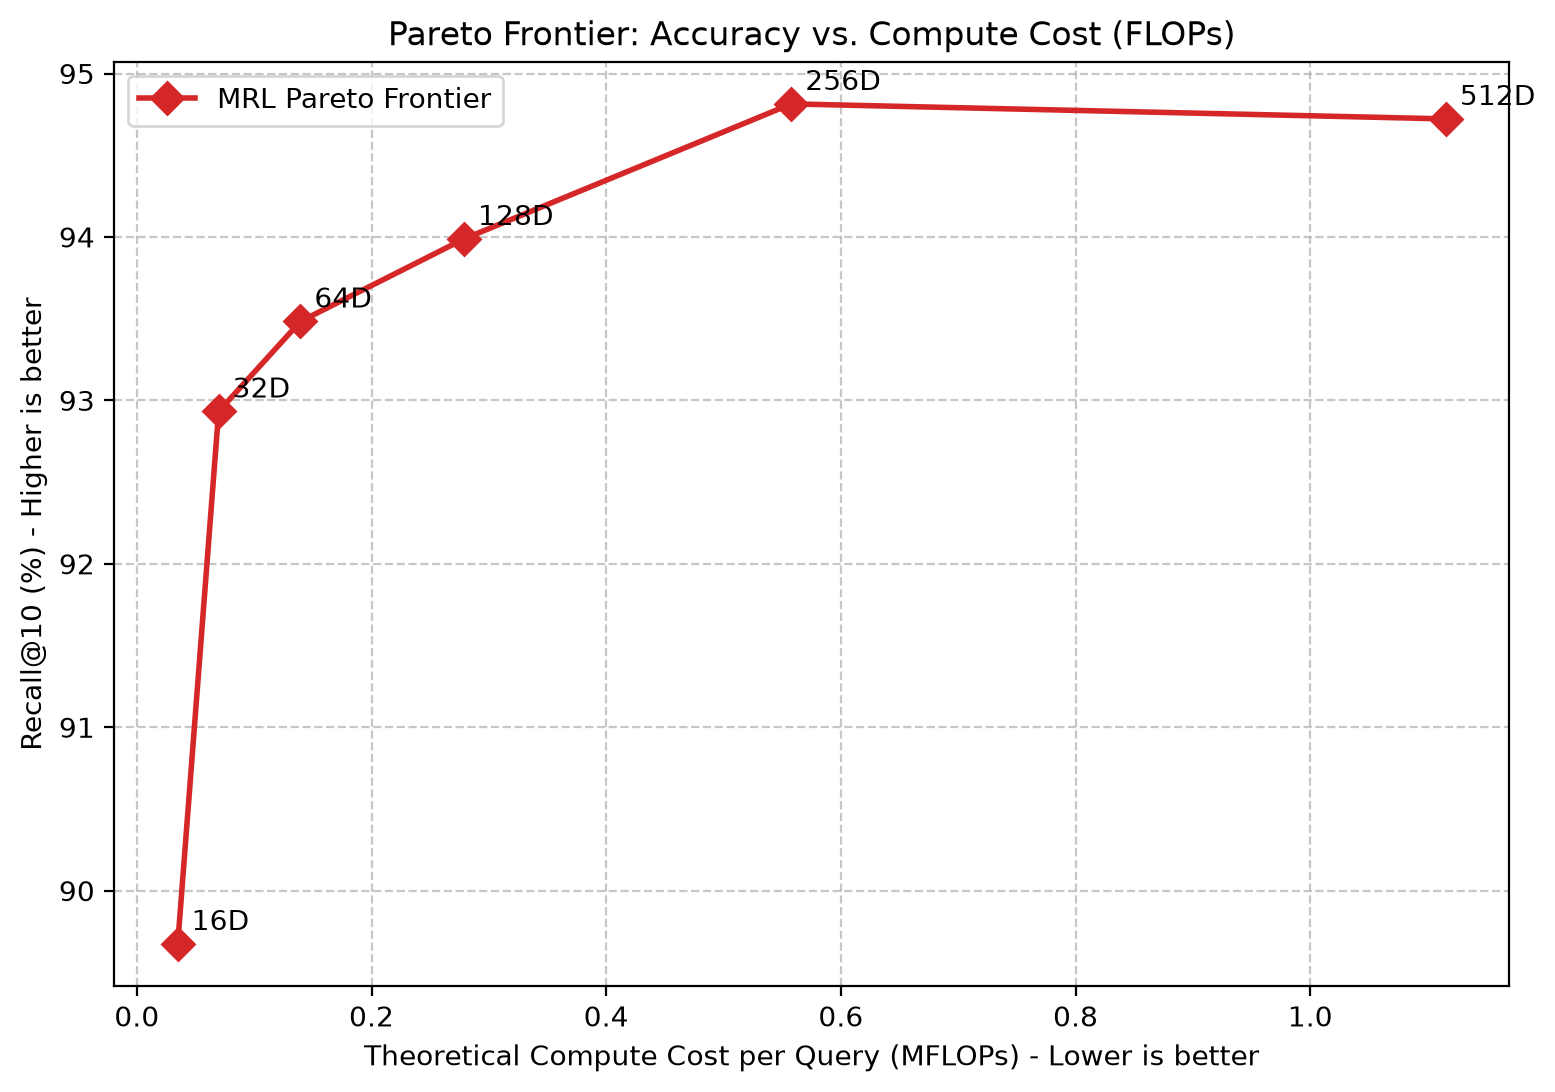

Conclusion: If the Pareto curve bends strongly toward the top-left corner (High Accuracy, Low Compute), your model has applied MRL very successfully!


In [10]:
# Theoretical compute cost: MFLOPs per query = Dimension * Database_Size / 1_000_000
db_size = image_features.shape[0]
mflops_per_query = [ (dim * db_size) / 1_000_000 for dim in mrl_dims ]

plt.figure(figsize=(9, 6))

# Plot the MRL Pareto Frontier
plt.plot(mflops_per_query, recall_at_10, marker='D', markersize=8, color='#d62728', linewidth=2, label='MRL Pareto Frontier')

for i, dim in enumerate(mrl_dims):
    plt.annotate(f'{dim}D', (mflops_per_query[i], recall_at_10[i]), 
                 textcoords="offset points", xytext=(5,5), ha='left', fontsize=10)

plt.title('Pareto Frontier: Accuracy vs. Compute Cost (FLOPs)')
plt.xlabel('Theoretical Compute Cost per Query (MFLOPs) - Lower is better')
plt.ylabel('Recall@10 (%) - Higher is better')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

print("Conclusion: If the Pareto curve bends strongly toward the top-left corner (High Accuracy, Low Compute), your model has applied MRL very successfully!")